# Tsinghua University - Deep Learning Course <br> Assignment 1(b) Softmax Regression

## 1. Load Dataset


In [1]:
import os
import pathlib
import tqdm
import numpy as np
import pickle
import zipfile
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
# Read from dataset file

with zipfile.ZipFile('data/cifar-10-python.zip', 'r') as z:
    def pickle_load_from_zip_entry(name):
        with z.open(name) as f:
            return pickle.load(f, encoding='latin1')

    label_names = pickle_load_from_zip_entry('cifar-10-batches-py/batches.meta')['label_names']
    print('label_names:', label_names)

    print('\nLoading train set ...')
    train_data_dicts = [
        pickle_load_from_zip_entry(f'cifar-10-batches-py/{filename}')
        for filename in ('data_batch_1', 'data_batch_2', 'data_batch_3', 'data_batch_4', 'data_batch_5',)]
    train_data = np.concatenate([d['data'].astype(np.float32) for d in train_data_dicts]) / 255.
    train_labels = np.concatenate([d['labels'] for d in train_data_dicts])
    print(f'train_data: <np.array of shape: {train_data.shape} dtype: {train_data.dtype}>')
    print(f'train_labels: <np.array of shape: {train_labels.shape} dtype: {train_labels.dtype}>')

    print('\nLoading test set ...')
    test_data_dict = pickle_load_from_zip_entry('cifar-10-batches-py/test_batch')
    test_data = test_data_dict['data'].astype(np.float32) / 255.
    test_labels = np.array(test_data_dict['labels'])
    print(f'test_data: <np.array of shape: {test_data.shape} dtype: {test_data.dtype}>')
    print(f'test_labels: <np.array of shape: {test_labels.shape} dtype: {test_labels.dtype}>')


label_names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Loading train set ...
train_data: <np.array of shape: (50000, 3072) dtype: float32>
train_labels: <np.array of shape: (50000,) dtype: int32>

Loading test set ...
test_data: <np.array of shape: (10000, 3072) dtype: float32>
test_labels: <np.array of shape: (10000,) dtype: int32>


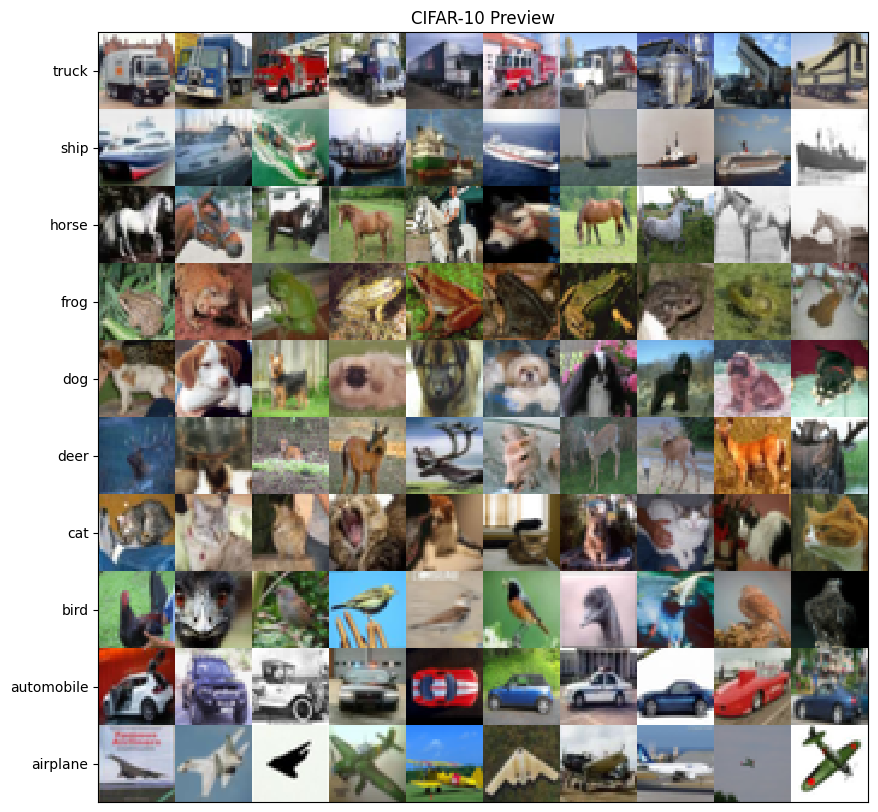

In [3]:
# Preview dataset

_ = plt.figure(figsize=(10, 10))
_ = plt.title('CIFAR-10 Preview')
for label_index, label_name in enumerate(label_names):
    for img_index, img_data in enumerate(test_data[test_labels == label_index][:10]):
        _ = plt.imshow(
            np.moveaxis(np.reshape(img_data, (3, 32, 32)), 0, 2),
            interpolation='nearest', extent=(img_index, img_index + 1, label_index, label_index + 1))
_ = plt.xticks([])
_ = plt.yticks(np.arange(len(label_names)) + 0.5, label_names)
_ = plt.xlim(0, 10)
_ = plt.ylim(0, len(label_names))

## 2. Training

In [ ]:
batch_size = 50
max_epoch = 10
lr = 0.001      # learning rate
momentum = 0.9  # momentum

fixed_steps = 500   # 固定每个 epoch 的更新次数

W = np.random.randn(3072, 10) * 0.001   # weight
b = np.zeros(10)                        # bias

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(max_epoch):
    steps_per_epoch = fixed_steps  # 固定 step 数
    progress_bar = tqdm.tqdm(range(steps_per_epoch))

    epoch_losses = []
    epoch_accuracies = []
    for step_index in progress_bar:
        # fetch next batch of training data
        idx = np.random.choice(len(train_data), batch_size)   # random sampling
        x = train_data[idx]
        y_true = train_labels[idx]
        y_true = np.eye(10)[y_true]                                                     # make one-hot (shape: [batch_size, 10])

        # TODO: forward with softmax
        y_pred = np.exp((z := x @ W + b) - np.max(z, axis=1, keepdims=True)); y_pred = y_pred / np.sum(y_pred, axis=1, keepdims=True)     # h_k(x) in the slides

        # TODO: calculate cross-entropy loss & accuracy
        loss = -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))
        accuracy = np.mean(np.argmax(y_pred, axis=1) == np.argmax(y_true, axis=1))

        epoch_losses.append(loss)
        epoch_accuracies.append(accuracy)
        progress_bar.set_description(f'loss {loss:.3f} acc {accuracy:.3f}')

        # TODO: update weights, don't forget momentum
        grad_W = x.T @ (y_pred - y_true) / batch_size
        grad_b = np.mean(y_pred - y_true, axis=0)
        W -= lr * grad_W
        b -= lr * grad_b

    train_losses.append(np.mean(epoch_losses))
    train_accuracies.append(np.mean(epoch_accuracies))

    # test accuracies
    x = test_data
    y_true = test_labels
    y_true = np.eye(10)[y_true]     # make one-hot

    # TODO: test set: forward with softmax
    y_pred = np.exp((z := x @ W + b) - np.max(z, axis=1, keepdims=True)); y_pred = y_pred / np.sum(y_pred, axis=1, keepdims=True)     # h_k(x) in the slides

    # TODO: test set: calculate cross-entropy loss & accuracy
    loss = -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))
    accuracy = np.mean(np.argmax(y_pred, axis=1) == np.argmax(y_true, axis=1))

    test_losses.append(loss)
    test_accuracies.append(accuracy)
    print(f'  - test acc: {accuracy:.3f}')

# plot loss & accuracy curve
fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 4))
a0.set_title('Losses')
a0.plot(train_losses, marker='.', label='train')
a0.plot(test_losses, marker='.', label='test')
a0.legend()
a1.set_title('Accuracies')
a1.plot(train_accuracies, marker='.', label='train')
a1.plot(test_accuracies, marker='.', label='test')
a1.legend()
plt.show()
